In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
#Load the Dataset
df=pd.read_csv("Food_Delivery_Times.csv")
df



,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68
...,...,...,...,...,...,...,...,...,...
995,107,8.50,Clear,High,Evening,Car,13,3.0,54
996,271,16.28,Rainy,Low,Morning,Scooter,8,9.0,71
997,861,15.62,Snowy,High,Evening,Scooter,26,2.0,81
998,436,14.17,Clear,Low,Afternoon,Bike,8,0.0,55


In [3]:
#data inspection (numeric and continuous value therefore it is regression problem)
print(df.shape)

(1000, 9)


In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                1000 non-null   int64  
 1   Distance_km             1000 non-null   float64
 2   Weather                 970 non-null    object 
 3   Traffic_Level           970 non-null    object 
 4   Time_of_Day             970 non-null    object 
 5   Vehicle_Type            1000 non-null   object 
 6   Preparation_Time_min    1000 non-null   int64  
 7   Courier_Experience_yrs  970 non-null    float64
 8   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 70.4+ KB
None


In [5]:
print(df.describe())

          Order_ID  Distance_km  Preparation_Time_min  Courier_Experience_yrs  \
count  1000.000000  1000.000000           1000.000000              970.000000   
mean    500.500000    10.059970             16.982000                4.579381   
std     288.819436     5.696656              7.204553                2.914394   
min       1.000000     0.590000              5.000000                0.000000   
25%     250.750000     5.105000             11.000000                2.000000   
50%     500.500000    10.190000             17.000000                5.000000   
75%     750.250000    15.017500             23.000000                7.000000   
max    1000.000000    19.990000             29.000000                9.000000   

       Delivery_Time_min  
count        1000.000000  
mean           56.732000  
std            22.070915  
min             8.000000  
25%            41.000000  
50%            55.500000  
75%            71.000000  
max           153.000000  


In [6]:
print(df.head())

   Order_ID  Distance_km Weather Traffic_Level Time_of_Day Vehicle_Type  \
0       522         7.93   Windy           Low   Afternoon      Scooter   
1       738        16.42   Clear        Medium     Evening         Bike   
2       741         9.52   Foggy           Low       Night      Scooter   
3       661         7.44   Rainy        Medium   Afternoon      Scooter   
4       412        19.03   Clear           Low     Morning         Bike   

   Preparation_Time_min  Courier_Experience_yrs  Delivery_Time_min  
0                    12                     1.0                 43  
1                    20                     2.0                 84  
2                    28                     1.0                 59  
3                     5                     1.0                 37  
4                    16                     5.0                 68  


In [7]:
print(df.tail())

     Order_ID  Distance_km Weather Traffic_Level Time_of_Day Vehicle_Type  \
995       107         8.50   Clear          High     Evening          Car   
996       271        16.28   Rainy           Low     Morning      Scooter   
997       861        15.62   Snowy          High     Evening      Scooter   
998       436        14.17   Clear           Low   Afternoon         Bike   
999       103         6.63   Foggy           Low       Night      Scooter   

     Preparation_Time_min  Courier_Experience_yrs  Delivery_Time_min  
995                    13                     3.0                 54  
996                     8                     9.0                 71  
997                    26                     2.0                 81  
998                     8                     0.0                 55  
999                    24                     3.0                 58  


In [8]:
print(df.sample())

    Order_ID  Distance_km Weather Traffic_Level Time_of_Day Vehicle_Type  \
33       500        19.73   Foggy        Medium     Evening         Bike   

    Preparation_Time_min  Courier_Experience_yrs  Delivery_Time_min  
33                    27                     4.0                111  


In [9]:
print(df.isnull().sum())

Order_ID                   0
Distance_km                0
Weather                   30
Traffic_Level             30
Time_of_Day               30
Vehicle_Type               0
Preparation_Time_min       0
Courier_Experience_yrs    30
Delivery_Time_min          0
dtype: int64


In [10]:
a=df.columns
print(a)

#check for unique and values counts of each column
for i in a:
    print(f"Column name: {i}")
    print("Unique values:")
    print(df[i].unique())
    print("Value counts:")
    print(df[i].value_counts())
    print("========================")

Index(['Order_ID', 'Distance_km', 'Weather', 'Traffic_Level', 'Time_of_Day',
       'Vehicle_Type', 'Preparation_Time_min', 'Courier_Experience_yrs',
       'Delivery_Time_min'],
      dtype='object')
Column name: Order_ID
Unique values:
[ 522  738  741  661  412  679  627  514  860  137  812   77  637  974
  939  900  281  884  762  320  550  175  372  528  211  236  102  987
  903  948  347  140  622  500  371  199  688  585  902   60  329   97
  313  975  300  278  925  602  440  838  571  880  262  579   24   31
  618   11  222  821  297   55  543  210  605  693  663  867   71  544
  108  494  591  742  293  290  653   40  590  308  680   67  276   68
  319  549  999  715  754  328  383  452  523  219  788  437  765   89
   64  827  717  352  937  257  636  645  555  960  169  918  529  824
  986  817   87  433  185  979  535  295  893  426  714  261  238  560
  584  446  868  801  600  850  266  996  530   56  121  216   26   73
   45  248  722  282  894  915  811  245  823  322  

In [11]:
df.dtypes

Order_ID                    int64
Distance_km               float64
Weather                    object
Traffic_Level              object
Time_of_Day                object
Vehicle_Type               object
Preparation_Time_min        int64
Courier_Experience_yrs    float64
Delivery_Time_min           int64
dtype: object

In [12]:
#Filling null values
df['Weather'].ffill(inplace=True)
df['Traffic_Level'].ffill(inplace=True)
df['Time_of_Day'].ffill(inplace=True)


C:\Users\blesi\AppData\Local\Temp\ipykernel_10392\3080059501.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Weather'].ffill(inplace=True)
C:\Users\blesi\AppData\Local\Temp\ipykernel_10392\3080059501.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doin

In [13]:
df['Courier_Experience_yrs'].fillna(df['Courier_Experience_yrs'].mean(),inplace=True)

C:\Users\blesi\AppData\Local\Temp\ipykernel_10392\1963837149.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Courier_Experience_yrs'].fillna(df['Courier_Experience_yrs'].mean(),inplace=True)


In [14]:
print(df.isnull().sum())

Order_ID                  0
Distance_km               0
Weather                   0
Traffic_Level             0
Time_of_Day               0
Vehicle_Type              0
Preparation_Time_min      0
Courier_Experience_yrs    0
Delivery_Time_min         0
dtype: int64


In [15]:
#Min and maximum delivery time
print("Minimum delivery time :",df['Delivery_Time_min'].min())
print("Maximum delivery time :",df['Delivery_Time_min'].max())

Minimum delivery time : 8
Maximum delivery time : 153


In [16]:
#Min and Maximum preparation time
print("Minimum Preparation time :",df['Preparation_Time_min'].min())
print("Maximum Preparation time :",df['Preparation_Time_min'].max())

Minimum Preparation time : 5
Maximum Preparation time : 29


In [17]:
#Min and Maximum courier experience years
print("Minimum Courier_Experience_yrs :",df['Courier_Experience_yrs'].min())
print("Maximum Courier_Experience_yrs :",df['Courier_Experience_yrs'].max())

Minimum Courier_Experience_yrs : 0.0
Maximum Courier_Experience_yrs : 9.0


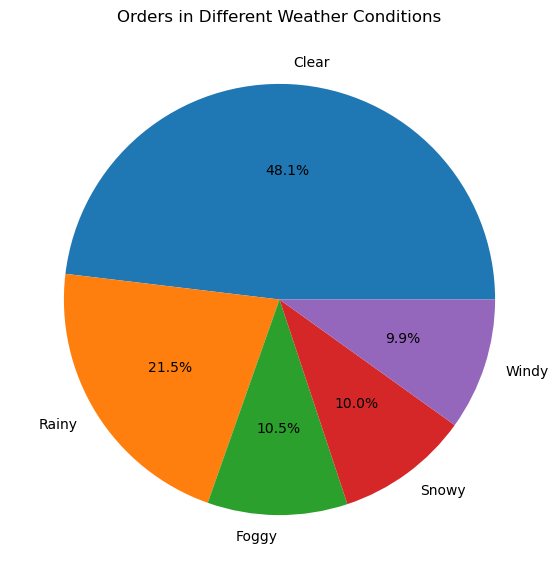

In [18]:
#Visualizations
# 1️⃣ Orders in Weather Condition – Pie Chart
weather_counts = df['Weather'].value_counts()

plt.figure(figsize=(7,7))
plt.pie(weather_counts.values, labels=weather_counts.index, autopct='%1.1f%%')
plt.title("Orders in Different Weather Conditions")
plt.show()



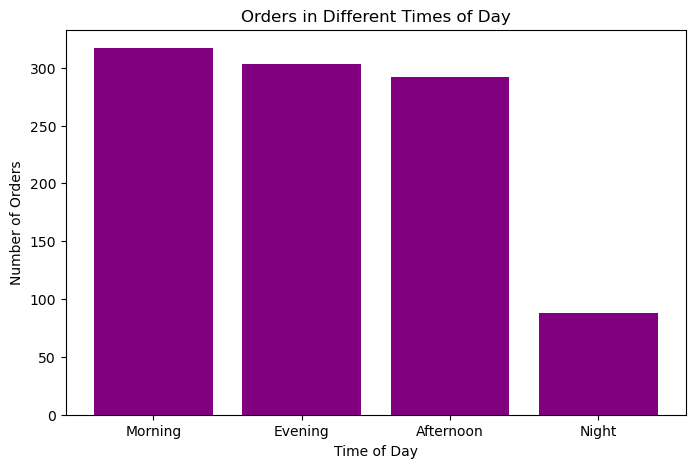

In [19]:
# 2️⃣ Orders in Different Time of Day – Bar Plot
time_counts = df['Time_of_Day'].value_counts()

plt.figure(figsize=(8,5))
plt.bar(time_counts.index, time_counts.values,color='Purple')
plt.title("Orders in Different Times of Day")
plt.xlabel("Time of Day")
plt.ylabel("Number of Orders")
plt.show()

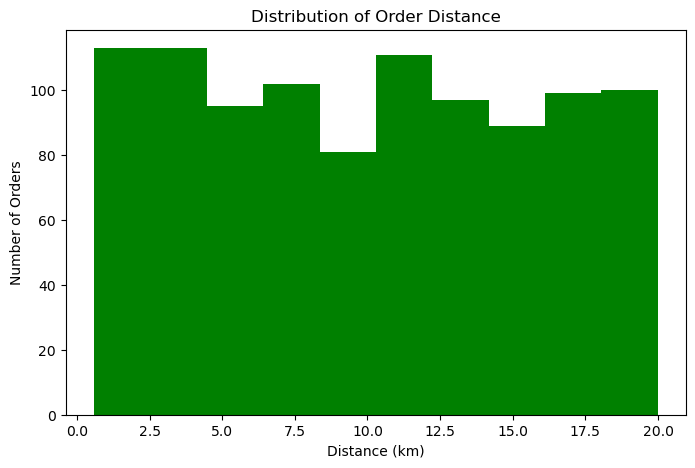

In [20]:
# 3️⃣ Orders by Distance – Histogram
plt.figure(figsize=(8,5))
plt.hist(df['Distance_km'], bins=10,color='green')
plt.title("Distribution of Order Distance")
plt.xlabel("Distance (km)")
plt.ylabel("Number of Orders")
plt.show()

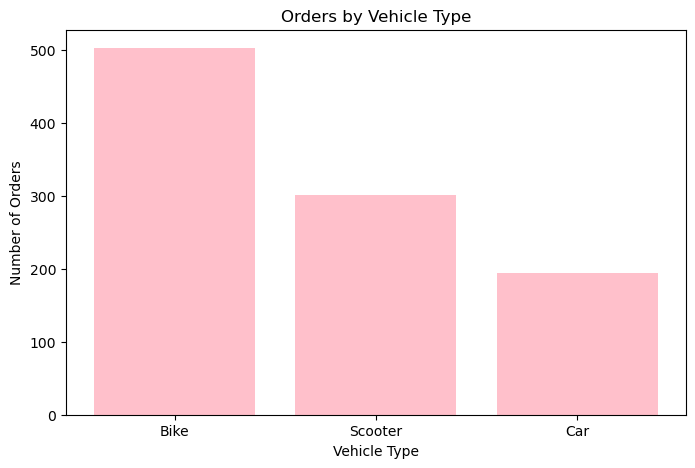

In [21]:
# 4️⃣ Orders by Vehicle Type – Bar Plot
vehicle_counts = df['Vehicle_Type'].value_counts()

plt.figure(figsize=(8,5))
plt.bar(vehicle_counts.index, vehicle_counts.values,color='pink')
plt.title("Orders by Vehicle Type")
plt.xlabel("Vehicle Type")
plt.ylabel("Number of Orders")
plt.show()


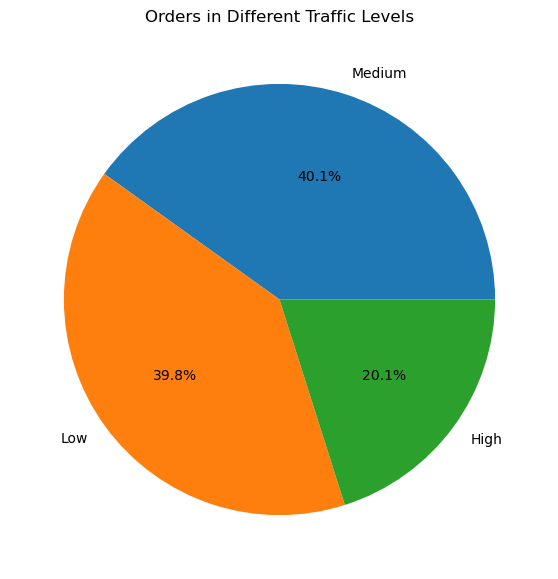

In [22]:
# 5️⃣ Orders by Traffic Level – Pie Chart
traffic_counts = df['Traffic_Level'].value_counts()

plt.figure(figsize=(7,7))
plt.pie(traffic_counts.values, labels=traffic_counts.index, autopct='%1.1f%%')
plt.title("Orders in Different Traffic Levels")
plt.show()

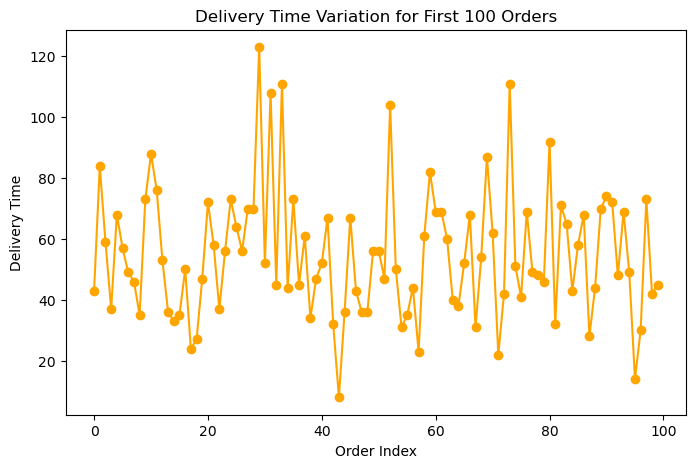

In [23]:
# Delivery Time Variation for First 100 Orders — Line Graph
import matplotlib.pyplot as plt
first_100 = df.head(100)

plt.figure(figsize=(8,5))
plt.plot(first_100.index, first_100['Delivery_Time_min'], marker='o',color='orange')

plt.title("Delivery Time Variation for First 100 Orders")
plt.xlabel("Order Index")
plt.ylabel("Delivery Time")
plt.show()

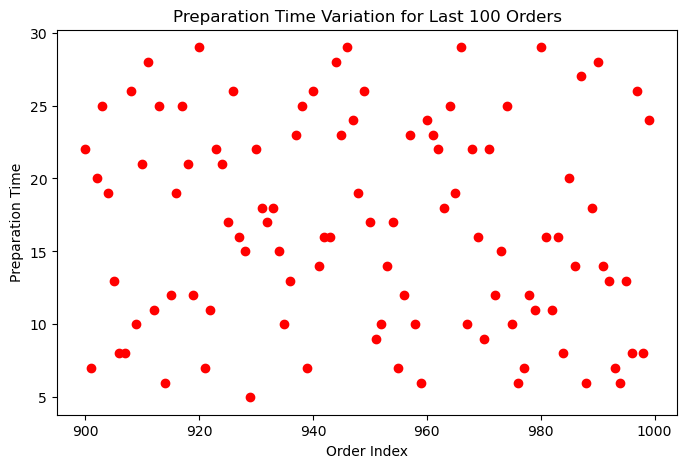

In [24]:
# Preparation Time Variation for Last 100 Orders — Scatter Plot
last_100 = df.tail(100)

plt.figure(figsize=(8,5))
plt.scatter(last_100.index, last_100['Preparation_Time_min'],color='red')

plt.title("Preparation Time Variation for Last 100 Orders")
plt.xlabel("Order Index")
plt.ylabel("Preparation Time")
plt.show()



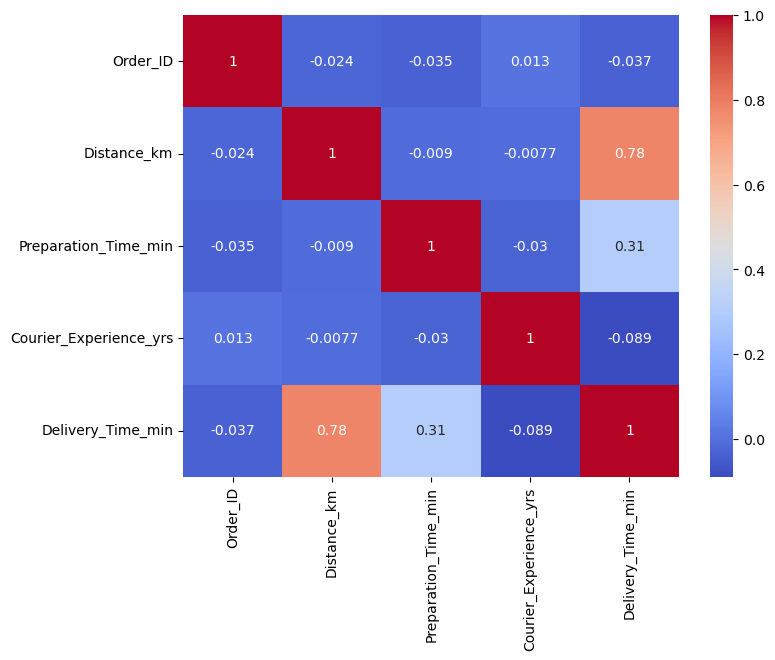

In [25]:
#Correlation Matrix//generally used for medical data
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap="coolwarm")
plt.show()

In [26]:
df.corr(numeric_only=True)["Delivery_Time_min"].sort_values(ascending=False)

Delivery_Time_min         1.000000
Distance_km               0.780998
Preparation_Time_min      0.307350
Order_ID                 -0.036650
Courier_Experience_yrs   -0.089066
Name: Delivery_Time_min, dtype: float64

In [27]:
#Drop unnecessary column
df.drop('Order_ID',axis=1,inplace=True)

In [28]:
df.columns

Index(['Distance_km', 'Weather', 'Traffic_Level', 'Time_of_Day',
       'Vehicle_Type', 'Preparation_Time_min', 'Courier_Experience_yrs',
       'Delivery_Time_min'],
      dtype='object')

In [29]:
#data encoding
#weather, Time_of_Day and 'Vehicle_Type' --nominal --dummy or one hot encoding
#traffic level---ordinal data --- label/mapping

In [30]:
#weather dummy encoding
df = pd.get_dummies(df, columns=['Weather', 'Time_of_Day', 'Vehicle_Type'],dtype='int')

In [31]:
#traffic level--- label encoding
traffic_map = {
    'Low': 1,
    'Medium': 2,
    'High': 3
}

df['Traffic_Level'] = df['Traffic_Level'].map(traffic_map)

In [32]:
df

,Distance_km,Traffic_Level,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min,Weather_Clear,Weather_Foggy,Weather_Rainy,Weather_Snowy,Weather_Windy,Time_of_Day_Afternoon,Time_of_Day_Evening,Time_of_Day_Morning,Time_of_Day_Night,Vehicle_Type_Bike,Vehicle_Type_Car,Vehicle_Type_Scooter
0,7.93,1,12,1.0,43,0,0,0,0,1,1,0,0,0,0,0,1
1,16.42,2,20,2.0,84,1,0,0,0,0,0,1,0,0,1,0,0
2,9.52,1,28,1.0,59,0,1,0,0,0,0,0,0,1,0,0,1
3,7.44,2,5,1.0,37,0,0,1,0,0,1,0,0,0,0,0,1
4,19.03,1,16,5.0,68,1,0,0,0,0,0,0,1,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,8.50,3,13,3.0,54,1,0,0,0,0,0,1,0,0,0,1,0
996,16.28,1,8,9.0,71,0,0,1,0,0,0,0,1,0,0,0,1
997,15.62,3,26,2.0,81,0,0,0,1,0,0,1,0,0,0,0,1
998,14.17,1,8,0.0,55,1,0,0,0,0,1,0,0,0,1,0,0


In [33]:
#labeling the data
x=df.drop('Delivery_Time_min',axis=1)
y=df['Delivery_Time_min']

In [34]:
print(x.columns)



Index(['Distance_km', 'Traffic_Level', 'Preparation_Time_min',
       'Courier_Experience_yrs', 'Weather_Clear', 'Weather_Foggy',
       'Weather_Rainy', 'Weather_Snowy', 'Weather_Windy',
       'Time_of_Day_Afternoon', 'Time_of_Day_Evening', 'Time_of_Day_Morning',
       'Time_of_Day_Night', 'Vehicle_Type_Bike', 'Vehicle_Type_Car',
       'Vehicle_Type_Scooter'],
      dtype='object')


In [35]:
#Splitting the data for train and test

from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42) 

In [36]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(800, 16)
(200, 16)
(800,)
(200,)


In [37]:
#model training---linear regression, decision tree regressor, random forest regressor, support vector regressor

In [38]:
#Linear Regression
from sklearn.linear_model import LinearRegression

lr=LinearRegression()

#training model
lr.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [39]:
#testing 

y_pred_lr=lr.predict(x_test)
y_pred_lr

array([35.51438007, 66.51535164, 44.83674125, 43.85758465, 85.75713927,
       32.38142925, 69.31711382, 33.15176689, 37.09754639, 77.22684844,
       74.26229162, 60.75875544, 35.70119251, 71.25254557, 88.90871791,
       83.19389883, 32.6924713 , 68.0727829 , 47.64586601, 53.25415503,
       85.9290455 , 27.65653161, 82.21201291, 71.72420805, 61.98976516,
       33.67828668, 84.98324331, 25.6440203 , 50.89908415, 66.98922952,
       68.91535788, 16.9443888 , 60.99778139, 38.58685633, 67.83177078,
       20.41654582, 62.55234056, 54.09516053, 47.13786603, 75.46291019,
       76.51622393, 31.41032996, 80.50706939, 70.50764907, 36.50840273,
       15.00612574, 91.68369816, 83.38636536, 78.49051464, 26.99221698,
       65.36391771, 57.64613669, 38.85338868, 79.433918  , 56.21619098,
       52.94446545, 75.79887505, 81.61255793, 66.47980486, 91.89975048,
       48.50554486, 36.38865826, 49.63014479, 48.35979099, 50.92474015,
       66.40575575, 61.95165582, 91.00353912, 75.82396991, 58.54

In [40]:
#model evalution


print("R^2 score of LR on training set:",lr.score(x_train,y_train))
print("R^2 score of LR on test set:",lr.score(x_test,y_test))


R^2 score of LR on training set: 0.7612336631588197
R^2 score of LR on test set: 0.8227781590116763


In [41]:
#Checking for error(checking wrong prediction)
# Root Mean Squared Error(RMSE): 8.912665689350597 --9 minutes
from sklearn.metrics import mean_absolute_error as mae,mean_squared_error as mse

print("---Linear Regression-Model evaluation---")
print("Mean Absolute Error(MAE):",mae(y_test,y_pred_lr)) 
print("Mean Squared Error(MSE):",mse(y_test,y_pred_lr))  
print("Root Mean Squared Error(RMSE):",np.sqrt(mse(y_test,y_pred_lr)))  

---Linear Regression-Model evaluation---
Mean Absolute Error(MAE): 5.971029213849797
Mean Squared Error(MSE): 79.43560969012735
Root Mean Squared Error(RMSE): 8.912665689350597


In [42]:
#decision tree
from sklearn.tree import DecisionTreeRegressor
dt_regressor=DecisionTreeRegressor()
dt_regressor.fit(x_train,y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [43]:
y_pred_dt=dt_regressor.predict(x_test)
print(y_pred_dt)

[ 29.  73.  30.  53. 102.  28.  70.  22.  27.  92.  75.  46.  25.  64.
 103.  83.  28.  57.  52.  50.  81.  32.  92.  48.  65.  70.  92.  22.
  42.  47.  74.  18.  50.  41.  79.   8.  58.  65.  36.  92.  66.  34.
  75.  57.  35.  14. 141.  69.  70.  28.  74.  54.  49.  68.  65.  50.
  71.  71.  53.  92.  65.  31.  59.  60.  44.  47.  66. 103.  71.  59.
  68.  34.  87.  25.  73.  63.  28.  49.  47.  27.  54.  77.  78.  27.
  21.  61.  63.  75.  37.  71.  45.  56.  50.  29.  58.  71.  46.  53.
  47.  70.  36.  48.  33.  27.  57.  16.  51.  17. 126.  39.  78.  54.
  59.  50.  74.  39.  80.  91.  27.  60.  52.  60.  47.  64.  58.  68.
  32.  47.  58.  41.  45.  48.  82.  58.  67.  39.  68.  66.  71.  72.
  41.  72.  71.  73.  59.  46.  87.  66. 123.  40.  42.  56.  82. 141.
  49.  35.  51.  32.  89.  71.  83.  90.  76.  46.  44.  68.  87.  78.
  49.  79.  49.  65.  41.  36.  22.  76.  62.  27.  87.  97.  49.  41.
  62.  37.  77.  43.  31.  71.  61.  27. 116.  16.  47.  43.  43.  77.
  32. 

In [44]:
from sklearn.metrics import mean_absolute_error as mae,mean_squared_error as mse
print("R^2 score of LR on training set:",dt_regressor.score(x_train,y_train))
print("R^2 score of LR on test set:",dt_regressor.score(x_test,y_test))

print("---Decision Tree-Model evaluation---")
print("Mean Absolute Error(MAE):",mae(y_test,y_pred_dt)) 
print("Mean Squared Error(MSE):",mse(y_test,y_pred_dt))  
print("Root Mean Squared Error(RMSE):",np.sqrt(mse(y_test,y_pred_dt)))

R^2 score of LR on training set: 1.0
R^2 score of LR on test set: 0.47927051913821117
---Decision Tree-Model evaluation---
Mean Absolute Error(MAE): 10.615
Mean Squared Error(MSE): 233.405
Root Mean Squared Error(RMSE): 15.277597978739983


In [45]:
#Random forest
from sklearn.ensemble import RandomForestRegressor
random_regressor=RandomForestRegressor()
random_regressor.fit(x_train,y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [46]:

y_pred_rf=random_regressor.predict(x_test)
print(y_pred_rf)

[34.64 67.97 41.56 45.08 85.1  35.11 66.75 34.59 34.53 76.78 75.33 61.23
 36.98 78.14 91.53 88.31 29.19 65.78 51.34 56.39 84.03 29.72 72.75 76.35
 62.2  34.65 81.63 24.53 50.19 62.24 68.9  20.56 55.48 39.04 73.74 16.13
 64.37 54.68 48.38 78.19 75.2  33.41 76.17 68.71 41.18 21.4  94.81 79.55
 82.6  29.91 66.53 58.18 38.93 79.38 54.76 51.69 75.91 79.12 61.94 87.26
 54.87 34.71 52.81 45.74 51.02 56.69 69.78 93.85 70.06 57.32 74.86 37.98
 85.98 26.74 66.02 65.4  41.76 42.   49.65 32.73 56.   71.7  63.43 28.42
 30.79 70.21 59.8  80.15 47.74 70.85 49.02 67.08 48.83 38.8  58.25 71.2
 52.39 52.18 39.77 39.93 31.23 53.94 29.28 27.62 52.08 21.43 46.29 17.28
 90.68 39.05 70.12 54.2  67.14 47.39 96.64 40.42 59.51 75.7  29.49 63.18
 58.46 78.18 53.94 63.11 49.69 67.38 35.78 63.5  50.16 43.38 45.15 54.36
 76.16 49.51 66.48 47.64 80.02 65.23 71.69 46.79 42.11 41.84 69.42 67.41
 49.66 59.77 89.14 67.07 87.64 36.43 38.55 63.09 60.12 97.72 41.55 25.5
 47.12 36.83 70.06 68.02 88.41 84.17 67.28 56.17 40.4

In [47]:
print("R^2 score of LR on training set:",random_regressor.score(x_train,y_train))
print("R^2 score of LR on test set:",random_regressor.score(x_test,y_test))

R^2 score of LR on training set: 0.9573208014446036
R^2 score of LR on test set: 0.7838912037812986


In [48]:
from sklearn.metrics import mean_absolute_error as mae,mean_squared_error as mse

print("---Random Forest-Model evaluation---")
print("Mean Absolute Error(MAE):",mae(y_test,y_pred_rf)) 
print("Mean Squared Error(MSE):",mse(y_test,y_pred_rf))  
print("Root Mean Squared Error(RMSE):",np.sqrt(mse(y_test,y_pred_rf))) 

---Random Forest-Model evaluation---
Mean Absolute Error(MAE): 6.8894
Mean Squared Error(MSE): 96.86579199999998
Root Mean Squared Error(RMSE): 9.84204206453112


In [49]:
#support Vector regressor
from sklearn.svm import SVR
svr=SVR()
svr.fit(x_train,y_train)

,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,1.0
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [50]:

y_pred_svr=svr.predict(x_test)
print(y_pred_svr)

[38.07172492 64.6334159  34.07726001 43.47311493 80.02132862 36.41875388
 63.64744858 33.06945373 29.05179584 66.1293531  69.53435158 64.50193371
 32.40297612 68.69504638 82.37907751 81.30043645 31.06286214 67.09675524
 43.17796677 59.25125203 79.60205953 28.04983432 69.14705833 71.50308543
 52.43479028 30.96507224 73.78917316 26.81864627 47.92755736 61.15158298
 58.04680664 26.18600204 57.93256069 41.12204269 69.09496672 26.67681975
 66.2958936  53.95261523 47.68902215 67.82275907 70.38400627 39.17590811
 69.4546199  67.09318004 33.42476115 25.63405743 81.06833831 79.91926298
 77.17434605 33.33567042 54.52416757 61.10108632 41.71076264 71.88285306
 51.28681335 54.43375793 69.67068892 71.02922107 59.5620521  81.50827858
 48.78619571 39.50559856 39.58522673 50.04699667 48.34332559 60.04830097
 67.76169948 81.53493436 59.3174791  48.74857752 70.568643   34.28500557
 80.13994647 30.07561508 65.05739065 54.54549688 40.67136374 40.9228367
 44.59989058 29.68329879 56.38089865 70.24870249 58.

In [51]:
print("R^2 score of svr on training set:",svr.score(x_train,y_train))
print("R^2 score of svr on test set:",svr.score(x_test,y_test))

R^2 score of svr on training set: 0.6910317627824856
R^2 score of svr on test set: 0.7335166428322517


In [52]:
from sklearn.metrics import mean_absolute_error as mae,mean_squared_error as mse

print("---Support Vector Regressor-Model evaluation---")
print("Mean Absolute Error(MAE):",mae(y_test,y_pred_svr)) 
print("Mean Squared Error(MSE):",mse(y_test,y_pred_svr))  
print("Root Mean Squared Error(RMSE):",np.sqrt(mse(y_test,y_pred_svr))) 

---Support Vector Regressor-Model evaluation---
Mean Absolute Error(MAE): 7.614886544512478
Mean Squared Error(MSE): 119.44502907114436
Root Mean Squared Error(RMSE): 10.929090953558047


In [55]:
#saving the models
import joblib

#save model
joblib.dump(lr,"delivery_time_model.pkl")

#save column structure (Very Important)
joblib.dump(x.columns.tolist(),"model_columns.pkl")

#Save label encoder (for Traffic_level)[ordinal encoding]
joblib.dump(traffic_map,"taffic_encoder.pkl")

print("Model saved successfully")

Model saved successfully


In [59]:
#testing
import joblib
import numpy as np

#Load saved model and encoder
model=joblib.load("delivery_time_model.pkl")
traffic_map=joblib.load("taffic_encoder.pkl")

In [66]:
#take user input
distance=float(input("Enter the distance: :"))
t_level=input("Enter the traffic level (Low/Medium/High):")
p_time=int(input("Enter the preparation time (minutes):"))
experience=float(input("Enter the courier experience (years):"))
weather=input("Enter the weather type (clear,foggy,rainy,snowy,windy):")        
time=input("Enter time of day (Morning, Afternoon, Evening, Night) :")
vehicle=input("Enter vehicle type (Bike, Car, Scooter) :")

#mapping
if t_level=="Low":
    t_level=0
elif t_level=="Medium":
    t_level=1
else:
    t_level=2

# #label enoding
# t_level=lb.transform([t_level])[0]

# Weather Encoding
Weather_Clear=0
Weather_Foggy=0
Weather_Rainy=0
Weather_Snowy=0
Weather_Windy=0

if weather == "Clear":
    Weather_Clear=1
elif weather == "Foggy":
    Weather_Foggy=1
elif weather == "Rainy":
    Weather_Rainy=1
elif weather =="Snowy":
    Weather_Snowy=1
else:
    Weather_Windy=1

# Time of Day encoding
Time_of_Day_Afternoon=0
Time_of_Day_Evening=0
Time_of_Day_Morning=0
Time_of_Day_Night=0

if time == "Morning":
    Time_of_Day_Morning=1
elif time == "Afternoon":
    Time_of_Day_Afternoon=1
elif time == "Evening":
    Time_of_Day_Evening=1
else:
    Time_of_Day_Night=1

#Vehicle encoding
Vehicle_Type_Bike=0
Vehicle_Type_Car=0
Vehicle_Type_Scooter=0

if vehicle == "Bike":
    Vehicle_Type_Bike=1
elif vehicle== "Car":
    Vehicle_Type_Car=1
else:
    Vehicle_Type_Scooter=1
#Feature vector

data=[[
distance,           
t_level,            
p_time,       
experience,   
Weather_Clear,             
Weather_Foggy,              
Weather_Rainy,               
Weather_Snowy,               
Weather_Windy,              
Time_of_Day_Afternoon,       
Time_of_Day_Evening,        
Time_of_Day_Morning,        
Time_of_Day_Night,          
Vehicle_Type_Bike,           
Vehicle_Type_Car,            
Vehicle_Type_Scooter]]

#covert to numpy
data=np.array(data)

#--Prediction

prediction=model.predict(data)[0]

print("\n Estimated Delivery time:",round(prediction,2),"minutes")

Enter the distance: : 3.85
Enter the traffic level (Low/Medium/High): Medium
Enter the preparation time (minutes): 26
Enter the courier experience (years): 3
Enter the weather type (clear,foggy,rainy,snowy,windy): Rainy
Enter time of day (Morning, Afternoon, Evening, Night) : Afternoon
Enter vehicle type (Bike, Car, Scooter) : Bike



 Estimated Delivery time: 46.37 minutes


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [61]:
print(df.sample(5))

     Distance_km  Traffic_Level  Preparation_Time_min  Courier_Experience_yrs  \
201        18.92              3                    27                4.000000   
308         3.85              2                    26                3.000000   
720         3.74              1                    19                6.000000   
307         3.37              3                     9                4.579381   
714        14.89              3                    22                9.000000   

     Delivery_Time_min  Weather_Clear  Weather_Foggy  Weather_Rainy  \
201                100              1              0              0   
308                 46              0              0              1   
720                 36              0              0              1   
307                 28              1              0              0   
714                 88              1              0              0   

     Weather_Snowy  Weather_Windy  Time_of_Day_Afternoon  Time_of_Day_Evening  \
201  

In [60]:
print(x.dtypes)

Distance_km               float64
Traffic_Level               int64
Preparation_Time_min        int64
Courier_Experience_yrs    float64
Weather_Clear               int64
Weather_Foggy               int64
Weather_Rainy               int64
Weather_Snowy               int64
Weather_Windy               int64
Time_of_Day_Afternoon       int64
Time_of_Day_Evening         int64
Time_of_Day_Morning         int64
Time_of_Day_Night           int64
Vehicle_Type_Bike           int64
Vehicle_Type_Car            int64
Vehicle_Type_Scooter        int64
dtype: object


In [70]:
import joblib
import numpy as np
import pandas as pd

# Load saved model and columns
model = joblib.load("delivery_time_model.pkl")
columns = joblib.load("model_columns.pkl")

# User inputs
distance = float(input("Enter the distance (km): "))
t_level = input("Enter the traffic level (Low/Medium/High): ").capitalize()
p_time = int(input("Enter the preparation time (minutes): "))
experience = float(input("Enter the courier experience (years): "))
weather = input("Enter the weather type (clear,foggy,rainy,snowy,windy): ").lower()
time = input("Enter time of day (Morning, Afternoon, Evening, Night): ").capitalize()
vehicle = input("Enter vehicle type (Bike, Car, Scooter): ").capitalize()

# Create dictionary with all columns initialized to 0
input_dict = {col: 0 for col in columns}

# Fill numerical values
input_dict['Distance_km'] = distance
input_dict['Preparation_Time_min'] = p_time
input_dict['Courier_Experience_yrs'] = experience

# Encode Traffic Level (Ordinal)
if t_level == "Low":
    input_dict['Traffic_Level'] = 0
elif t_level == "Medium":
    input_dict['Traffic_Level'] = 1
elif t_level == "High":
    input_dict['Traffic_Level'] = 2
else:
    print("Invalid Traffic Level! Defaulting to Medium")
    input_dict['Traffic_Level'] = 1

# Dummy encoding safely
# Weather
weather_col = f"Weather_{weather}"
if weather_col in input_dict:
    input_dict[weather_col] = 1

# Time of Day
time_col = f"Time_of_Day_{time}"
if time_col in input_dict:
    input_dict[time_col] = 1

# Vehicle Type
vehicle_col = f"Vehicle_Type_{vehicle}"
if vehicle_col in input_dict:
    input_dict[vehicle_col] = 1

# Convert to DataFrame
input_df = pd.DataFrame([input_dict])

# Ensure correct column order
input_df = input_df[columns]

# Prediction
pred = model.predict(input_df)

# Output result
print("Predicted delivery time:", round(pred[0], 2), "minutes")

Enter the distance (km):  3.85
Enter the traffic level (Low/Medium/High):  Medium
Enter the preparation time (minutes):  26
Enter the courier experience (years):  3
Enter the weather type (clear,foggy,rainy,snowy,windy):  Rainy
Enter time of day (Morning, Afternoon, Evening, Night):  Afternoon
Enter vehicle type (Bike, Car, Scooter):  Bike


Predicted delivery time: 45.7 minutes
